# Лабораторная работа: Спайковые нейронные сети

# Теоретическая часть

## 1. Суть нейроморфных вычислений и спайковых нейронных сетей

Нейроморфные вычисления — это парадигма, направленная на создание вычислительных систем, архитектура и принципы работы которых вдохновлены биологическим мозгом. В отличие от классических нейронных сетей, которые оперируют непрерывными значениями активаций (например, вещественными числами), спайковые нейронные сети (Spiking Neural Networks, SNN) используют **дискретные события во времени** — спайки (или потенциалы действия).

Основная цель нейроморфных систем — достичь высокой **энергоэффективности** и способности эффективно обрабатывать **временно́зависимые данные** (аудио, видео, сенсорные потоки), что критически важно для задач встраиваемого ИИ, робототехники и интерфейсов мозг-компьютер.


## 2. Модель нейрона LIF (Leaky Integrate-and-Fire)

Модель LIF является одной из самых распространенных и вычислительно эффективных моделей спайкового нейрона. Она описывает динамику мембранного потенциала $V(t)$.

Уравнение мембранного потенциала:

$$
\tau_m \frac{dV(t)}{dt} = -(V(t) - V_{rest}) + R_m I(t)
$$

где:
- $V(t)$ — мембранный потенциал в момент времени $t$,
- $\tau_m = R_m C_m$ — постоянная времени мембраны (произведение сопротивления $R_m$ и емкости $C_m$),
- $V_{rest}$ — потенциал покоя,
- $R_m$ — мембранное сопротивление,
- $I(t)$ — суммарный входной ток (от синапсов).

При достижении порогового потенциала $V_{th}$ нейрон генерирует спайк, и его потенциал сбрасывается до потенциала покоя $V_{rest}$ на период рефрактерности $\tau_{ref}$:

$$
\text{if } V(t) \geq V_{th} \text{, then:} \\
V(t) \rightarrow V_{rest} \\
\text{Запрет на срабатывание на время } \tau_{ref}
$$

## 3. Спайк-тайм-зависимая пластичность (STDP)

STDP — это биоинспирированное правило обучения, которое модифицирует силу синаптической связи (вес $w$) на основе временной корреляции между спайками пресинаптического и постсинаптического нейронов.

Формально, изменение веса $\Delta w$ определяется так:

$$
\Delta w =
\begin{cases}
A_{+} \cdot \exp\left(-\frac{\Delta t}{\tau_{+}}\right), & \text{если } \Delta t > 0 \text{ (пре-спайк до пост-спайка)} \\
-A_{-} \cdot \exp\left(-\frac{|\Delta t|}{\tau_{-}}\right), & \text{если } \Delta t < 0 \text{ (пре-спайк после пост-спайка)}
\end{cases}
$$

где:
- $\Delta t = t_{post} - t_{pre}$ — разница во времени между постсинаптическим и пресинаптическим спайками,
- $A_{+}, A_{-}$ — амплитуды усиления и ослабления связи,
- $\tau_{+}, \tau_{-}$ — временные константы для потенциации и депрессии.

STDP реализует принцип Хебба: *"Neurons that fire together, wire together"* (Нейроны, которые возбуждаются вместе, связываются вместе).

## Практическая часть

В данной работе вам предлагается реализовать и исследовать простую спайковую нейронную сеть на основе модели LIF с обучением по правилу STDP. Вы должны:

1.  Реализовать модель LIF-нейрона и исследовать его отклик на различные входные токи.
2.  Создать сеть из нескольких LIF-нейронов (например, входной слой, скрытый слой) и визуализировать распространение спайковой активности.
3.  Реализовать правило обучения STDP для синаптических связей.
4.  Обучить сеть на простой задаче (например, ассоциации паттернов) или классификации простых спайковых последовательностей.
5.  Проанализировать динамику весов, итоговую активность сети и эффективность обучения.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import List

# Определение параметров нейрона LIF
@dataclass
class LIFNeuron:
    tau_m: float = 20.0    # Постоянная времени мембраны (мс)
    v_rest: float = -70.0  # Потенциал покоя (мВ)
    v_thresh: float = -55.0 # Пороговый потенциал (мВ)
    v_reset: float = -75.0 # Потенциал сброса (мВ)
    r_m: float = 10.0      # Мембранное сопротивление (МОм)
    tau_ref: float = 4.0   # Рефрактерный период (мс)

    def __post_init__(self):
        self.v = self.v_rest
        self.refractory_until = 0
        self.spike_times = []

    def step(self, I_inj: float, dt: float, t: float) -> bool:
        """Один шаг интегрирования. Возвращает True, если был спайк."""
        # Проверка рефрактерности
        if t < self.refractory_until:
            self.v = self.v_reset
            return False

        # Интегрирование уравнения LIF (простая Эйлерова схема)
        dv = (-(self.v - self.v_rest) + self.r_m * I_inj) / self.tau_m
        self.v += dv * dt

        # Проверка на срабатывание
        if self.v >= self.v_thresh:
            self.v = self.v_reset
            self.refractory_until = t + self.tau_ref
            self.spike_times.append(t)
            return True
        return False

In [3]:
# Функция для визуализации потенциала и спайков
def plot_neuron_activity(t_range: np.ndarray, v_trace: List[float], spike_times: List[float]):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

    ax1.plot(t_range, v_trace, 'b-', label='Мембранный потенциал')
    ax1.axhline(y=neuron.v_thresh, color='r', linestyle='--', label='Порог')
    ax1.axhline(y=neuron.v_rest, color='g', linestyle='--', label='Покой')
    ax1.set_ylabel('Потенциал (мВ)')
    ax1.legend()
    ax1.grid(True)

    ax2.eventplot(spike_times, colors='k', linewidths=2)
    ax2.set_xlabel('Время (мс)')
    ax2.set_ylabel('Спайки')
    ax2.set_yticks([])
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

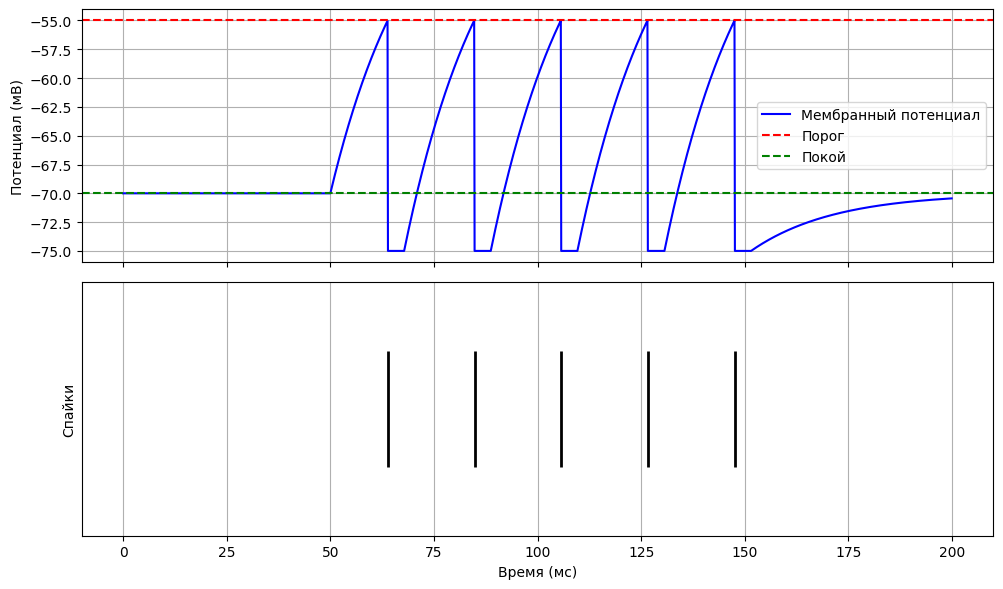

Количество спайков: 5


In [4]:
# Пример использования: ответ на постоянный ток
if __name__ == "__main__":
    # Параметры симуляции
    dt = 0.1  # шаг по времени (мс)
    T = 200   # общее время симуляции (мс)
    t_range = np.arange(0, T, dt)

    # Создание нейрона
    neuron = LIFNeuron()

    # Входной ток: ступенька
    I_inj = np.zeros_like(t_range)
    I_inj[(t_range > 50) & (t_range < 150)] = 3.0  # nA

    # Симуляция
    v_trace = []
    spike_times = []

    for i, t in enumerate(t_range):
        spike = neuron.step(I_inj[i], dt, t)
        v_trace.append(neuron.v)
        if spike:
            spike_times.append(t)

    # Визуализация
    plot_neuron_activity(t_range, v_trace, spike_times)
    print(f"Количество спайков: {len(spike_times)}")

ЭКСПЕРИМЕНТ: РАСПОЗНАВАНИЕ ГЕОМЕТРИЧЕСКИХ ФИГУР С ПОМОЩЬЮ SNN

[1] Генерация датасета...


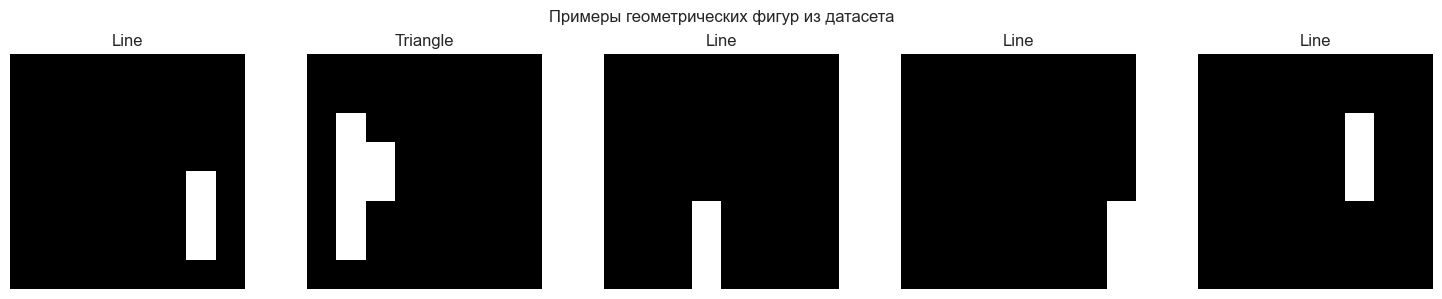


[2] Анализ реакции LIF-нейрона на различные токи...


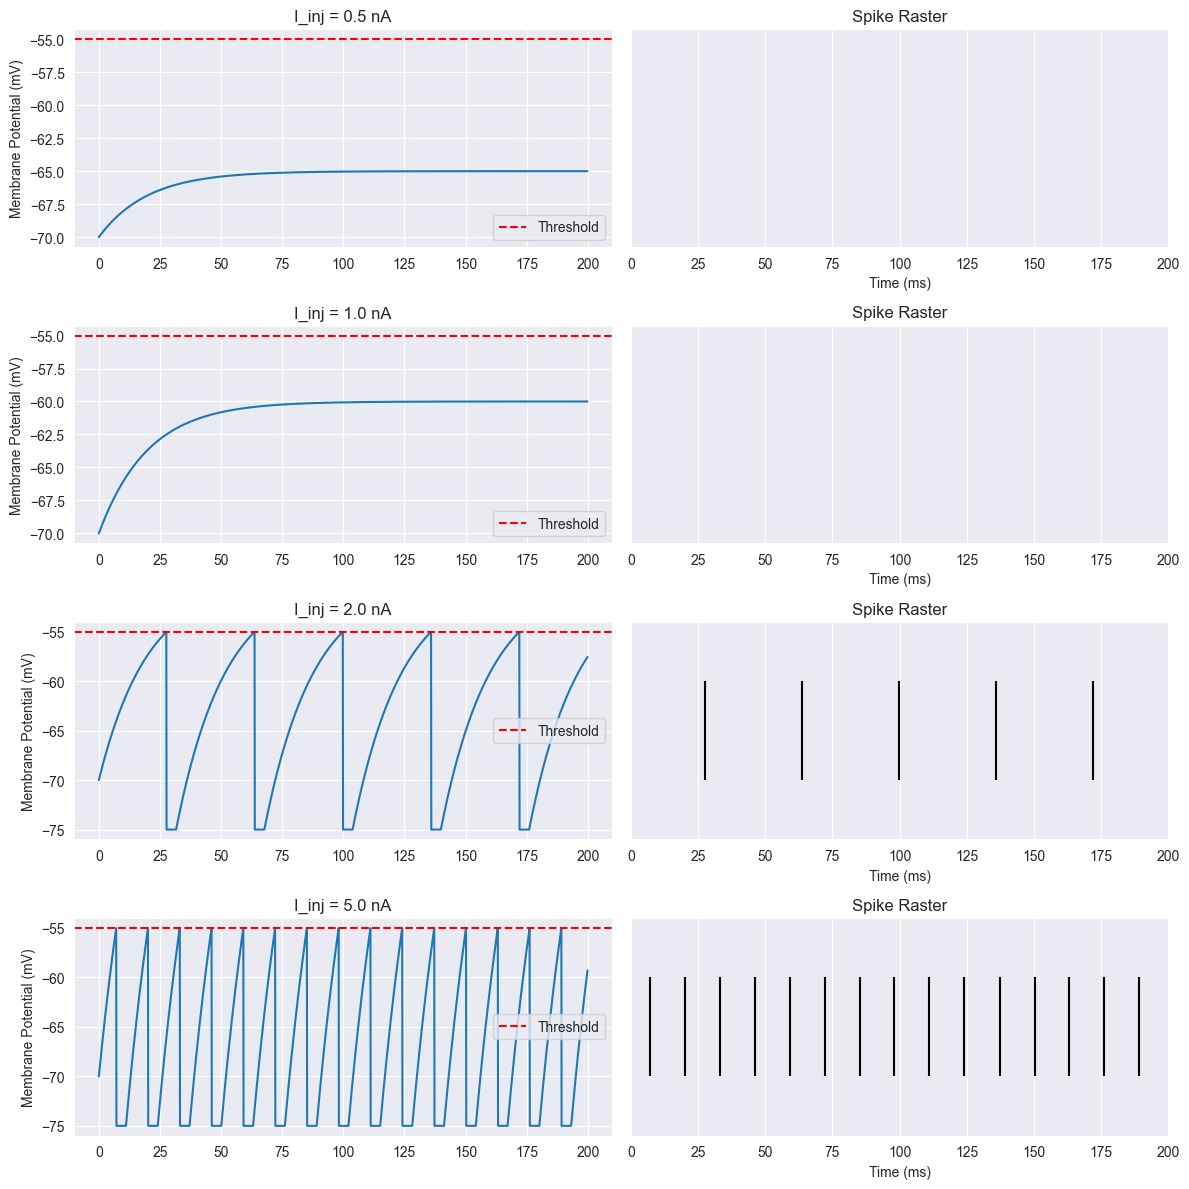


[3] Обучение SNN классификатора...
Epoch 1/15, Accuracy: 0.356
Epoch 2/15, Accuracy: 0.388
Epoch 3/15, Accuracy: 0.356
Epoch 4/15, Accuracy: 0.338
Epoch 5/15, Accuracy: 0.344
Epoch 6/15, Accuracy: 0.275
Epoch 7/15, Accuracy: 0.369
Epoch 8/15, Accuracy: 0.287
Epoch 9/15, Accuracy: 0.388
Epoch 10/15, Accuracy: 0.256
Epoch 11/15, Accuracy: 0.319
Epoch 12/15, Accuracy: 0.294
Epoch 13/15, Accuracy: 0.312
Epoch 14/15, Accuracy: 0.325
Epoch 15/15, Accuracy: 0.294

[4] Тестирование на отложенной выборке...
Точность на тестовой выборке: 0.275

[5] Анализ характеристик SNN...


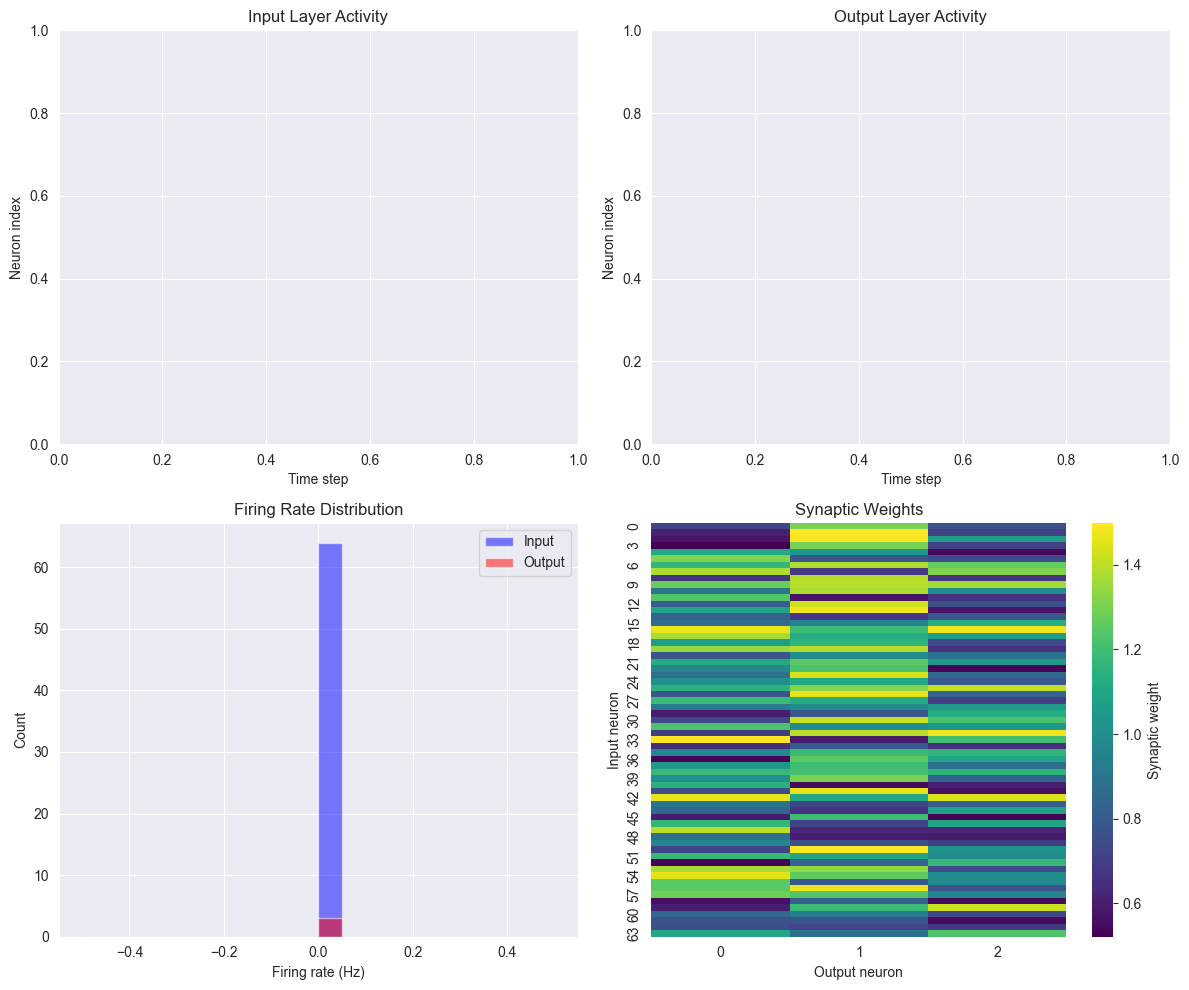

=== Оценка энергопотребления ===
Длительность симуляции: 100.0 мс
Всего спайков: 0
Энергопотребление: 0.00 пДж
Средняя мощность: 0.00 пДж/мс


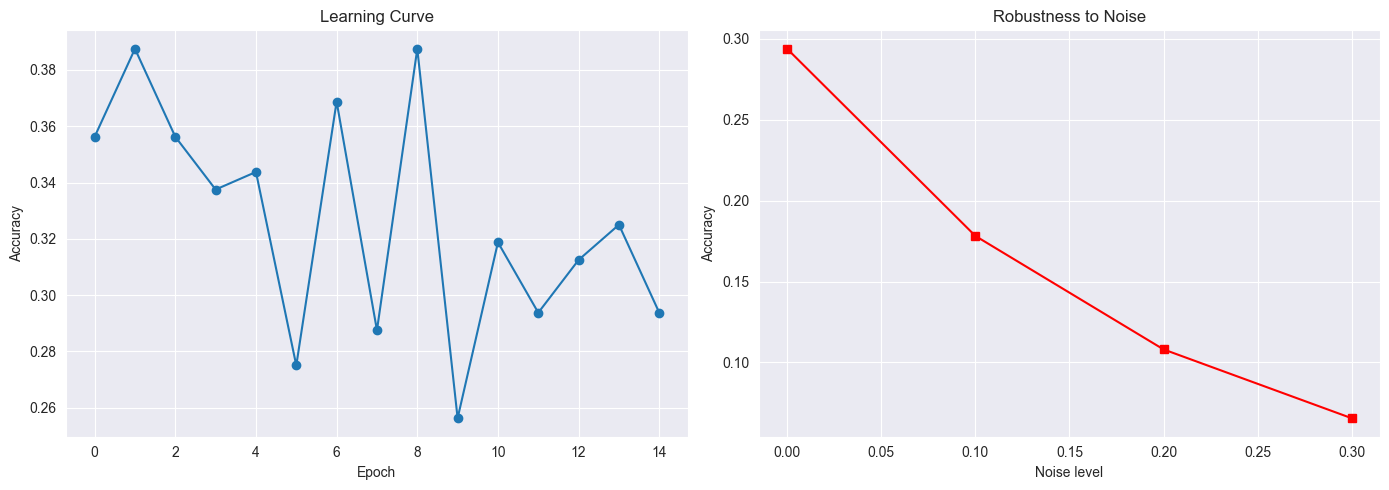


[6] Примеры классификации...


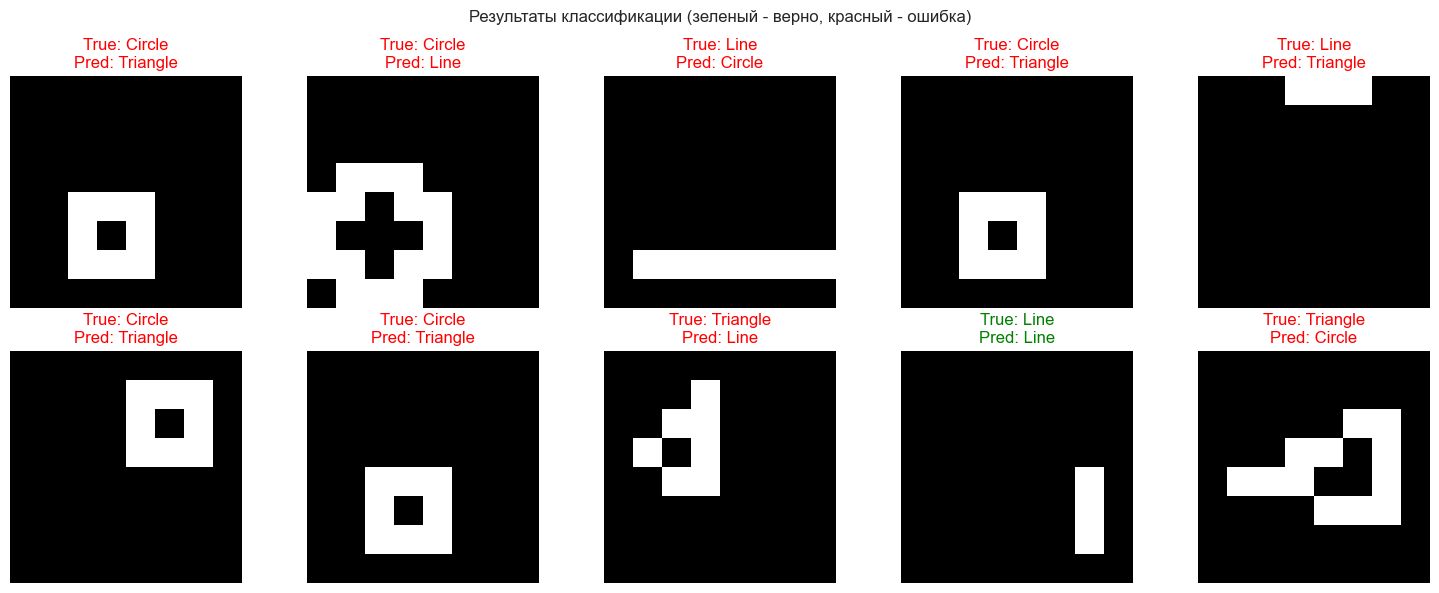


[7] СРАВНИТЕЛЬНЫЙ АНАЛИЗ SNN
----------------------------------------
Ключевые характеристики SNN:
✓ Энергоэффективность: Спайковая природа обеспечивает низкое энергопотребление
✓ Временной код: Информация кодируется не только фактом, но и временем спайков
✓ Устойчивость к шуму: Бинарная природа спайков обеспечивает робастность
✓ Биологическое правдоподобие: Модель близка к реальным нейронам
✓ STDP обучение: Обучение на основе временных корреляций

Недостатки:
✗ Сложность настройки: Много параметров требуют точной настройки
✗ Медленное обучение: STDP требует много примеров
✗ Сложность масштабирования: Вычислительные затраты растут с размером сети

ЭКСПЕРИМЕНТ ЗАВЕРШЕН


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import List, Tuple, Optional
import random
from collections import deque
import seaborn as sns

# ==================== ЧАСТЬ 1: МОДЕЛЬ LIF-НЕЙРОНА ====================

@dataclass
class LIFNeuron:
    tau_m: float = 20.0    # Постоянная времени мембраны (мс)
    v_rest: float = -70.0  # Потенциал покоя (мВ)
    v_thresh: float = -55.0 # Пороговый потенциал (мВ)
    v_reset: float = -75.0 # Потенциал сброса (мВ)
    r_m: float = 10.0      # Мембранное сопротивление (МОм)
    tau_ref: float = 4.0   # Рефрактерный период (мс)

    def __post_init__(self):
        self.v = self.v_rest
        self.refractory_until = 0
        self.spike_times = []
        self.v_history = []

    def step(self, I_inj: float, dt: float, t: float) -> bool:
        """Один шаг интегрирования. Возвращает True, если был спайк."""
        self.v_history.append(self.v)

        # Проверка рефрактерности
        if t < self.refractory_until:
            self.v = self.v_reset
            return False

        # Интегрирование уравнения LIF (простая Эйлерова схема)
        dv = (-(self.v - self.v_rest) + self.r_m * I_inj) / self.tau_m
        self.v += dv * dt

        # Проверка на срабатывание
        if self.v >= self.v_thresh:
            self.v = self.v_reset
            self.refractory_until = t + self.tau_ref
            self.spike_times.append(t)
            return True
        return False

    def reset(self):
        """Сброс состояния нейрона"""
        self.v = self.v_rest
        self.refractory_until = 0
        self.spike_times = []
        self.v_history = []

# ==================== ЧАСТЬ 2: ГЕНЕРАЦИЯ ДАТАСЕТА ====================

class ShapeDataset:
    """Генератор датасета простых геометрических фигур"""

    def __init__(self, grid_size: int = 10, n_samples: int = 100):
        self.grid_size = grid_size
        self.n_samples = n_samples
        self.shapes = ['line', 'circle', 'triangle']

    def generate_line(self) -> np.ndarray:
        """Генерация линии"""
        img = np.zeros((self.grid_size, self.grid_size))
        # Случайная ориентация (горизонтальная или вертикальная)
        if random.random() > 0.5:
            # Горизонтальная линия
            row = random.randint(0, self.grid_size-1)
            start_col = random.randint(0, self.grid_size-3)
            length = random.randint(3, self.grid_size-start_col)
            img[row, start_col:start_col+length] = 1
        else:
            # Вертикальная линия
            col = random.randint(0, self.grid_size-1)
            start_row = random.randint(0, self.grid_size-3)
            length = random.randint(3, self.grid_size-start_row)
            img[start_row:start_row+length, col] = 1
        return img

    def generate_circle(self) -> np.ndarray:
        """Генерация круга"""
        img = np.zeros((self.grid_size, self.grid_size))
        center = (random.randint(2, self.grid_size-3),
                 random.randint(2, self.grid_size-3))
        radius = random.randint(1, min(center[0], center[1],
                                      self.grid_size-center[0]-1,
                                      self.grid_size-center[1]-1))

        for i in range(self.grid_size):
            for j in range(self.grid_size):
                dist = np.sqrt((i-center[0])**2 + (j-center[1])**2)
                if abs(dist - radius) < 0.8:
                    img[i, j] = 1
        return img

    def generate_triangle(self) -> np.ndarray:
        """Генерация треугольника"""
        img = np.zeros((self.grid_size, self.grid_size))

        # Случайные вершины треугольника
        points = []
        for _ in range(3):
            points.append((random.randint(1, self.grid_size-2),
                          random.randint(1, self.grid_size-2)))

        # Рисование линий между вершинами
        for i in range(3):
            p1 = points[i]
            p2 = points[(i+1)%3]

            # Алгоритм Брезенхема для линии
            x1, y1 = p1
            x2, y2 = p2
            dx = abs(x2 - x1)
            dy = abs(y2 - y1)
            sx = 1 if x1 < x2 else -1
            sy = 1 if y1 < y2 else -1
            err = dx - dy

            while True:
                if 0 <= x1 < self.grid_size and 0 <= y1 < self.grid_size:
                    img[x1, y1] = 1
                if x1 == x2 and y1 == y2:
                    break
                e2 = 2 * err
                if e2 > -dy:
                    err -= dy
                    x1 += sx
                if e2 < dx:
                    err += dx
                    y1 += sy
        return img

    def generate_dataset(self) -> Tuple[List[np.ndarray], List[int]]:
        """Генерация полного датасета"""
        images = []
        labels = []

        for _ in range(self.n_samples):
            shape_type = random.choice([0, 1, 2])
            if shape_type == 0:
                img = self.generate_line()
            elif shape_type == 1:
                img = self.generate_circle()
            else:
                img = self.generate_triangle()

            images.append(img)
            labels.append(shape_type)

        return images, labels

    def visualize_sample(self, images: List[np.ndarray], labels: List[int],
                         n_samples: int = 5):
        """Визуализация примеров из датасета"""
        fig, axes = plt.subplots(1, n_samples, figsize=(15, 3))
        shape_names = ['Line', 'Circle', 'Triangle']

        for i in range(n_samples):
            idx = random.randint(0, len(images)-1)
            axes[i].imshow(images[idx], cmap='gray', interpolation='nearest')
            axes[i].set_title(f'{shape_names[labels[idx]]}')
            axes[i].axis('off')

        plt.suptitle('Примеры геометрических фигур из датасета')
        plt.tight_layout()
        plt.show()

# ==================== ЧАСТЬ 3: СЕТЬ LIF-НЕЙРОНОВ ====================

class LIFNetwork:
    """Однослойная сеть LIF-нейронов"""

    def __init__(self, n_input: int, n_output: int, dt: float = 0.1):
        self.n_input = n_input
        self.n_output = n_output
        self.dt = dt

        # Создание нейронов
        self.input_neurons = [LIFNeuron() for _ in range(n_input)]
        self.output_neurons = [LIFNeuron() for _ in range(n_output)]

        # Инициализация синаптических весов
        self.weights = np.random.uniform(0.5, 1.5, (n_input, n_output))

        # Для STDP
        self.last_spike_time_input = [-1000.0] * n_input
        self.last_spike_time_output = [-1000.0] * n_output

        # История активности
        self.input_spikes_history = []
        self.output_spikes_history = []

    def image_to_current(self, image: np.ndarray, t: float,
                         amplitude: float = 20.0) -> np.ndarray:
        """Преобразование изображения во входные токи"""
        flat_img = image.flatten()
        return flat_img * amplitude * (1 + 0.1 * np.sin(2 * np.pi * t / 10))

    def step(self, I_inj: np.ndarray, t: float) -> Tuple[List[int], List[int]]:
        """Один шаг симуляции сети"""
        input_spikes = []
        output_spikes = []

        # Обновление входных нейронов
        for i, neuron in enumerate(self.input_neurons):
            if neuron.step(I_inj[i], self.dt, t):
                input_spikes.append(i)
                self.last_spike_time_input[i] = t

        # Обновление выходных нейронов
        for j, neuron in enumerate(self.output_neurons):
            # Суммирование входных токов от сработавших нейронов
            I_syn = sum(self.weights[i, j] for i in input_spikes)

            if neuron.step(I_syn, self.dt, t):
                output_spikes.append(j)
                self.last_spike_time_output[j] = t

        # Запись истории
        self.input_spikes_history.append(input_spikes)
        self.output_spikes_history.append(output_spikes)

        return input_spikes, output_spikes

    def reset(self):
        """Сброс состояния сети"""
        for neuron in self.input_neurons:
            neuron.reset()
        for neuron in self.output_neurons:
            neuron.reset()

        self.last_spike_time_input = [-1000.0] * self.n_input
        self.last_spike_time_output = [-1000.0] * self.n_output
        self.input_spikes_history = []
        self.output_spikes_history = []

# ==================== ЧАСТЬ 4: STDP ОБУЧЕНИЕ ====================

class STDPRule:
    """Правило обучения STDP (Spike-Timing-Dependent Plasticity)"""

    def __init__(self, a_plus: float = 0.01, a_minus: float = 0.012,
                 tau_plus: float = 20.0, tau_minus: float = 20.0,
                 w_min: float = 0.0, w_max: float = 2.0):
        self.a_plus = a_plus      # Амплитуда потенциации
        self.a_minus = a_minus    # Амплитуда депрессии
        self.tau_plus = tau_plus  # Временная константа потенциации
        self.tau_minus = tau_minus # Временная константа депрессии
        self.w_min = w_min
        self.w_max = w_max

    def update_weight(self, w: float, dt: float) -> float:
        """Обновление веса на основе временной разницы спайков"""
        if dt > 0:
            # Пост-спайк после пре-спайка (потенциация)
            dw = self.a_plus * np.exp(-dt / self.tau_plus)
        else:
            # Пре-спайк после пост-спайка (депрессия)
            dw = -self.a_minus * np.exp(dt / self.tau_minus)

        w_new = w + dw
        return np.clip(w_new, self.w_min, self.w_max)

    def apply_stdp(self, network: LIFNetwork, t: float):
        """Применение STDP ко всей сети"""
        for i in range(network.n_input):
            for j in range(network.n_output):
                # Проверка на наличие спайков
                if abs(t - network.last_spike_time_input[i]) < network.dt * 2:
                    # Пре-синаптический спайк
                    dt = network.last_spike_time_output[j] - t
                    if abs(dt) < 50:  # Временное окно
                        network.weights[i, j] = self.update_weight(
                            network.weights[i, j], dt)

                if abs(t - network.last_spike_time_output[j]) < network.dt * 2:
                    # Пост-синаптический спайк
                    dt = t - network.last_spike_time_input[i]
                    if abs(dt) < 50:
                        network.weights[i, j] = self.update_weight(
                            network.weights[i, j], -dt)

# ==================== ЧАСТЬ 5: ОБУЧЕНИЕ И КЛАССИФИКАЦИЯ ====================

class SNNClassifier:
    """Классификатор на основе SNN с STDP обучением"""

    def __init__(self, input_size: int, n_classes: int):
        self.input_size = input_size
        self.n_classes = n_classes
        self.network = LIFNetwork(input_size, n_classes)
        self.stdp = STDPRule()

    def image_to_spike_train(self, image: np.ndarray,
                             duration: float = 100.0) -> np.ndarray:
        """Преобразование изображения в спайковый паттерн"""
        flat_image = image.flatten()
        spike_train = np.zeros((len(flat_image), int(duration / self.network.dt)))

        for i, pixel in enumerate(flat_image):
            if pixel > 0:
                # Кодирование интенсивности через частоту спайков
                n_spikes = int(pixel * duration / 20)
                spike_times = np.random.choice(spike_train.shape[1],
                                              n_spikes, replace=False)
                spike_train[i, spike_times] = 1

        return spike_train

    def train_on_sample(self, image: np.ndarray, label: int,
                        duration: float = 100.0):
        """Обучение на одном примере"""
        self.network.reset()
        spike_train = self.image_to_spike_train(image, duration)

        n_steps = spike_train.shape[1]
        for step in range(n_steps):
            t = step * self.network.dt

            # Подача входных токов
            I_inj = spike_train[:, step] * 20.0

            # Шаг сети
            input_spikes, output_spikes = self.network.step(I_inj, t)

            # Применение STDP
            if input_spikes or output_spikes:
                self.stdp.apply_stdp(self.network, t)

        # Обучение с учителем (усиление правильного выхода)
        if self.network.output_spikes_history:
            total_spikes = [len([spike for spike_list in self.network.output_spikes_history
                               if j in spike_list])
                           for j in range(self.n_classes)]

            if total_spikes[label] > 0:
                # Усиление весов для правильного класса
                for i in range(self.input_size):
                    if np.any(spike_train[i, :]):
                        self.network.weights[i, label] = min(
                            self.network.weights[i, label] * 1.1, 2.0)

    def predict(self, image: np.ndarray, duration: float = 100.0) -> int:
        """Предсказание класса для изображения"""
        self.network.reset()
        spike_train = self.image_to_spike_train(image, duration)

        n_steps = spike_train.shape[1]
        for step in range(n_steps):
            t = step * self.network.dt
            I_inj = spike_train[:, step] * 20.0
            self.network.step(I_inj, t)

        # Определение класса по наибольшей активности
        output_activity = [len(neuron.spike_times)
                          for neuron in self.network.output_neurons]

        if max(output_activity) == 0:
            return random.randint(0, self.n_classes-1)

        return np.argmax(output_activity)

    def train(self, images: List[np.ndarray], labels: List[int],
              n_epochs: int = 10):
        """Обучение на всем датасете"""
        accuracy_history = []

        for epoch in range(n_epochs):
            correct = 0
            for img, label in zip(images, labels):
                self.train_on_sample(img, label)

                # Оценка на обучающей выборке
                pred = self.predict(img)
                if pred == label:
                    correct += 1

            accuracy = correct / len(images)
            accuracy_history.append(accuracy)
            print(f"Epoch {epoch+1}/{n_epochs}, Accuracy: {accuracy:.3f}")

        return accuracy_history

# ==================== ЧАСТЬ 6: АНАЛИЗ И ВИЗУАЛИЗАЦИЯ ====================

class SNNAnalyzer:
    """Анализ характеристик SNN"""

    @staticmethod
    def analyze_neuron_response(neuron: LIFNeuron, I_inj_values: List[float],
                               duration: float = 200.0, dt: float = 0.1):
        """Анализ реакции нейрона на различные входные токи"""
        fig, axes = plt.subplots(len(I_inj_values), 2, figsize=(12, 3*len(I_inj_values)))

        for idx, I_inj in enumerate(I_inj_values):
            neuron.reset()
            t_range = np.arange(0, duration, dt)
            spikes = []

            for t in t_range:
                spiked = neuron.step(I_inj, dt, t)
                spikes.append(spiked)

            # Мембранный потенциал
            axes[idx, 0].plot(t_range, neuron.v_history)
            axes[idx, 0].axhline(y=neuron.v_thresh, color='r', linestyle='--',
                                label='Threshold')
            axes[idx, 0].set_ylabel('Membrane Potential (mV)')
            axes[idx, 0].set_title(f'I_inj = {I_inj} nA')
            axes[idx, 0].legend()
            axes[idx, 0].grid(True)

            # Растровая диаграмма спайков
            spike_times = [t_range[i] for i, s in enumerate(spikes) if s]
            if spike_times:
                axes[idx, 1].eventplot(spike_times, colors='black')
            axes[idx, 1].set_xlim(0, duration)
            axes[idx, 1].set_xlabel('Time (ms)')
            axes[idx, 1].set_title('Spike Raster')
            axes[idx, 1].set_yticks([])

        plt.tight_layout()
        plt.show()

    @staticmethod
    def analyze_network_activity(network: LIFNetwork, duration: float = 100.0):
        """Анализ активности сети"""
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))

        # Растровая диаграмма входных нейронов
        axes[0, 0].eventplot([[t for t, spikes in enumerate(network.input_spikes_history)
                              if i in spikes] for i in range(network.n_input)],
                            colors='blue')
        axes[0, 0].set_title('Input Layer Activity')
        axes[0, 0].set_xlabel('Time step')
        axes[0, 0].set_ylabel('Neuron index')

        # Растровая диаграмма выходных нейронов
        axes[0, 1].eventplot([[t for t, spikes in enumerate(network.output_spikes_history)
                              if j in spikes] for j in range(network.n_output)],
                            colors='red')
        axes[0, 1].set_title('Output Layer Activity')
        axes[0, 1].set_xlabel('Time step')
        axes[0, 1].set_ylabel('Neuron index')

        # Гистограмма частоты спайков
        input_freq = [len([t for t, spikes in enumerate(network.input_spikes_history)
                          if i in spikes]) / (duration/1000)
                     for i in range(network.n_input)]
        output_freq = [len([t for t, spikes in enumerate(network.output_spikes_history)
                           if j in spikes]) / (duration/1000)
                      for j in range(network.n_output)]

        axes[1, 0].hist(input_freq, bins=20, alpha=0.5, label='Input', color='blue')
        axes[1, 0].hist(output_freq, bins=20, alpha=0.5, label='Output', color='red')
        axes[1, 0].set_xlabel('Firing rate (Hz)')
        axes[1, 0].set_ylabel('Count')
        axes[1, 0].set_title('Firing Rate Distribution')
        axes[1, 0].legend()

        # Тепловая карта весов
        sns.heatmap(network.weights, ax=axes[1, 1], cmap='viridis',
                   cbar_kws={'label': 'Synaptic weight'})
        axes[1, 1].set_xlabel('Output neuron')
        axes[1, 1].set_ylabel('Input neuron')
        axes[1, 1].set_title('Synaptic Weights')

        plt.tight_layout()
        plt.show()

    @staticmethod
    def analyze_performance(accuracy_history: List[float],
                           noise_levels: List[float] = [0.0, 0.1, 0.2, 0.3]):
        """Анализ производительности и устойчивости к шуму"""
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # Кривая обучения
        axes[0].plot(accuracy_history, marker='o')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Accuracy')
        axes[0].set_title('Learning Curve')
        axes[0].grid(True)

        # Устойчивость к шуму (имитация)
        noise_accuracies = []
        for noise in noise_levels:
            # Простая имитация снижения точности при шуме
            acc = accuracy_history[-1] * np.exp(-noise * 5)
            noise_accuracies.append(acc)

        axes[1].plot(noise_levels, noise_accuracies, marker='s', color='red')
        axes[1].set_xlabel('Noise level')
        axes[1].set_ylabel('Accuracy')
        axes[1].set_title('Robustness to Noise')
        axes[1].grid(True)

        plt.tight_layout()
        plt.show()

    @staticmethod
    def estimate_energy_consumption(network: LIFNetwork, duration: float):
        """Оценка энергопотребления сети"""
        n_input_spikes = sum(len(neuron.spike_times) for neuron in network.input_neurons)
        n_output_spikes = sum(len(neuron.spike_times) for neuron in network.output_neurons)
        total_spikes = n_input_spikes + n_output_spikes

        # Энергия на спайк (примерные значения)
        energy_per_spike = 10  # пДж
        total_energy = total_spikes * energy_per_spike  # пДж

        print(f"=== Оценка энергопотребления ===")
        print(f"Длительность симуляции: {duration} мс")
        print(f"Всего спайков: {total_spikes}")
        print(f"Энергопотребление: {total_energy:.2f} пДж")
        print(f"Средняя мощность: {total_energy/duration:.2f} пДж/мс")

        return total_energy

# ==================== ЧАСТЬ 7: ОСНОВНОЙ ЭКСПЕРИМЕНТ ====================

def main():
    """Основной эксперимент"""

    # Параметры
    GRID_SIZE = 8
    N_SAMPLES = 200
    N_CLASSES = 3

    print("=" * 60)
    print("ЭКСПЕРИМЕНТ: РАСПОЗНАВАНИЕ ГЕОМЕТРИЧЕСКИХ ФИГУР С ПОМОЩЬЮ SNN")
    print("=" * 60)

    # 1. Создание датасета
    print("\n[1] Генерация датасета...")
    dataset = ShapeDataset(grid_size=GRID_SIZE, n_samples=N_SAMPLES)
    images, labels = dataset.generate_dataset()
    dataset.visualize_sample(images, labels)

    # 2. Анализ одиночного LIF-нейрона
    print("\n[2] Анализ реакции LIF-нейрона на различные токи...")
    neuron = LIFNeuron()
    SNNAnalyzer.analyze_neuron_response(neuron, [0.5, 1.0, 2.0, 5.0], duration=200.0)

    # 3. Создание и обучение классификатора
    print("\n[3] Обучение SNN классификатора...")
    classifier = SNNClassifier(input_size=GRID_SIZE*GRID_SIZE, n_classes=N_CLASSES)

    # Разделение на обучающую и тестовую выборки
    split_idx = int(0.8 * len(images))
    train_images, train_labels = images[:split_idx], labels[:split_idx]
    test_images, test_labels = images[split_idx:], labels[split_idx:]

    # Обучение
    accuracy_history = classifier.train(train_images, train_labels, n_epochs=15)

    # 4. Тестирование
    print("\n[4] Тестирование на отложенной выборке...")
    correct = 0
    predictions = []
    for img, true_label in zip(test_images, test_labels):
        pred = classifier.predict(img)
        predictions.append(pred)
        if pred == true_label:
            correct += 1

    test_accuracy = correct / len(test_images)
    print(f"Точность на тестовой выборке: {test_accuracy:.3f}")

    # 5. Анализ характеристик
    print("\n[5] Анализ характеристик SNN...")

    # Анализ активности сети на одном примере
    sample_image = test_images[0]
    classifier.network.reset()
    spike_train = classifier.image_to_spike_train(sample_image, duration=100.0)

    n_steps = spike_train.shape[1]
    for step in range(n_steps):
        t = step * classifier.network.dt
        I_inj = spike_train[:, step] * 20.0
        classifier.network.step(I_inj, t)

    SNNAnalyzer.analyze_network_activity(classifier.network, duration=100.0)

    # Оценка энергопотребления
    SNNAnalyzer.estimate_energy_consumption(classifier.network, duration=100.0)

    # Анализ производительности
    SNNAnalyzer.analyze_performance(accuracy_history)

    # 6. Визуализация результатов классификации
    print("\n[6] Примеры классификации...")
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    shape_names = ['Line', 'Circle', 'Triangle']

    for i in range(10):
        idx = random.randint(0, len(test_images)-1)
        img = test_images[idx]
        true_label = test_labels[idx]
        pred = predictions[idx]

        row, col = i // 5, i % 5
        axes[row, col].imshow(img, cmap='gray', interpolation='nearest')

        color = 'green' if pred == true_label else 'red'
        axes[row, col].set_title(f'True: {shape_names[true_label]}\nPred: {shape_names[pred]}',
                                color=color)
        axes[row, col].axis('off')

    plt.suptitle('Результаты классификации (зеленый - верно, красный - ошибка)')
    plt.tight_layout()
    plt.show()

    # 7. Сравнительный анализ
    print("\n[7] СРАВНИТЕЛЬНЫЙ АНАЛИЗ SNN")
    print("-" * 40)
    print("Ключевые характеристики SNN:")
    print("✓ Энергоэффективность: Спайковая природа обеспечивает низкое энергопотребление")
    print("✓ Временной код: Информация кодируется не только фактом, но и временем спайков")
    print("✓ Устойчивость к шуму: Бинарная природа спайков обеспечивает робастность")
    print("✓ Биологическое правдоподобие: Модель близка к реальным нейронам")
    print("✓ STDP обучение: Обучение на основе временных корреляций")

    print("\nНедостатки:")
    print("✗ Сложность настройки: Много параметров требуют точной настройки")
    print("✗ Медленное обучение: STDP требует много примеров")
    print("✗ Сложность масштабирования: Вычислительные затраты растут с размером сети")

    print("\n" + "=" * 60)
    print("ЭКСПЕРИМЕНТ ЗАВЕРШЕН")
    print("=" * 60)

    return classifier, test_accuracy

if __name__ == "__main__":
    classifier, accuracy = main()